In [4]:
from axeap_bo import xes_calc
from axeap_bo import xes_fit
from axeap_bo import bayes_opt
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Introduction

Let's say we have just measured the K$\beta$ XES of Mn2+. The spectrum is shown below:

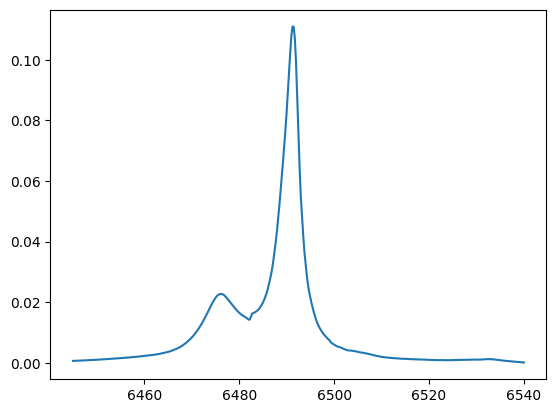

In [25]:
exp_data = pd.read_excel("./test_files/conv_Mn2.xlsx", sheet_name="MnO_bkgrmv", dtype=float)
exp_x = exp_data["DataX"].to_numpy(dtype=float)
exp_y = exp_data["DataY"].to_numpy(dtype=float)

plt.plot(exp_x, exp_y)
plt.show()

# Plotting Theoretical Spectra

We can plot a theoretical spectra of Mn2+ xes_calc and xes_fit modules. The xes_calc.gen_sticks() function will generate the theoretical emission probabilities, while the xes_fit.pvoigt_gen() function will broaden the probabilities into a spectrum. 

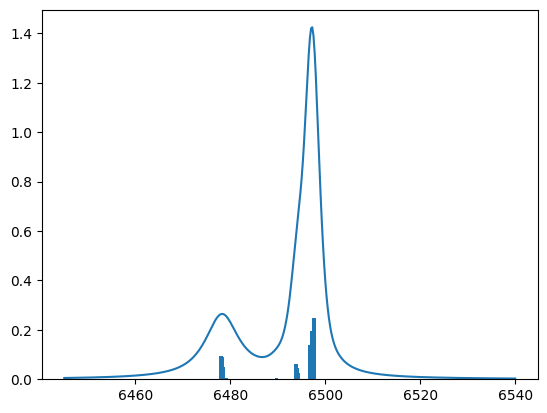

In [26]:
stick_x, stick_y = xes_calc.gen_sticks("Mn", "2+")
spec = xes_fit.pvoigt_gen(exp_x, stick_x, stick_y)
plt.bar(stick_x, stick_y/np.sum(stick_y))
plt.plot(exp_x, spec)
plt.show()

# Fitting to experimental spectra

If we compare our generated spectra to our experimentally measured one, we can see that they don't quite match. 

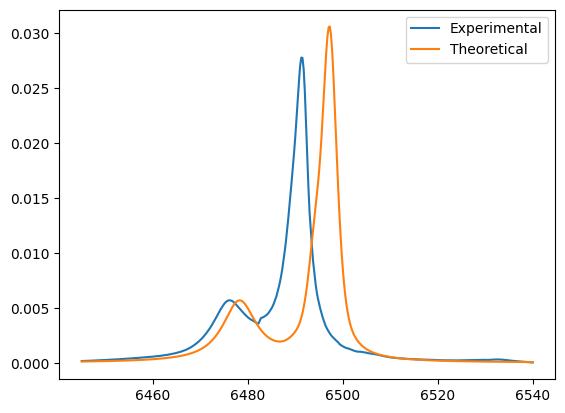

In [27]:
plt.plot(exp_x, exp_y/np.sum(exp_y), label="Experimental")
plt.plot(exp_x, spec/np.sum(spec), label="Theoretical")
plt.legend()
plt.show()

Notably, there appears to be an energy shift in the experimental spectrum. The nls_fit function in the xes_fit module uses non-linear least squares fitting to adjust the spectral parameters of a theoretical spectra to best fit an experimental one. 

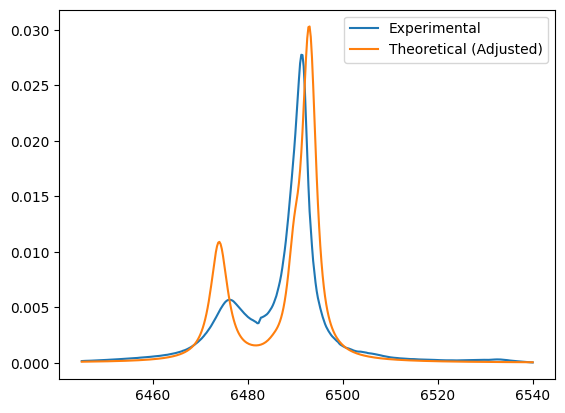

In [21]:
res = xes_fit.min_fit(exp_x, exp_y, stick_x, stick_y)
spec = xes_fit.pvoigt_gen(exp_x, stick_x, stick_y, *res.x)
plt.plot(exp_x, exp_y/np.sum(exp_y), label="Experimental")
plt.plot(exp_x, spec/np.sum(spec), label="Theoretical (Adjusted)")
plt.legend()
plt.show()

We can see now that the fit is much better! The energy shift has been resolved, and the peak positions of both spectra are much closer together. This enables a more direct comparison of the spectra. Although we have improved the fit, the shape and intensity of the peaks still do not match.

# Bayesian Optimization

We now turn to the multiplet parameters used in the spectral calculation. These empirical parameters can be optimized using Bayesian optimization to best fit a given experimental spectra, using the methods in the bayes_opt module. If we want to find the optimal $G_{pd}$ value, for example:

In [22]:
varis = ["gpd", "fdd"]
bounds = [(0.0, 100.0), (0.0, 100.0)]

varis = [("gpd", 0, None), ("fdd", 0, 100)]


res = bayes_opt.simul_opt("Mn", "2+", exp_x, exp_y, varis, bounds, n_calls=15, n_initial_points=5)
print(res)

[2.]
[100.0, 100.0, 5.001116152896181, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
0.11521473801903905
[100.0, 100.0, 47.0060915417282, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
0.11972080527558034
[100.0, 100.0, 92.48403765969465, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
0.04751896583211939
[100.0, 100.0, 49.28790158311558, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
0.07160734907482524
[100.0, 100.0, 38.0375792317864, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
0.0838715280384374
[100.0, 100.0, 93.03023160059432, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
0.04842031640563174
[100.0, 100.0, 100.0, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
5.093732735794771
[100.0, 100.0, 92.76192598047649, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
0.048401159747043836
[100.0, 100.0, 39.754392921939804, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
0.0820984532985811
[100.0, 100.0, 13.41850119173326, 100.0

If we use our newly optimized value of $G_{pd}$ to generate a theoretical spectra, we find that the fit is much better.

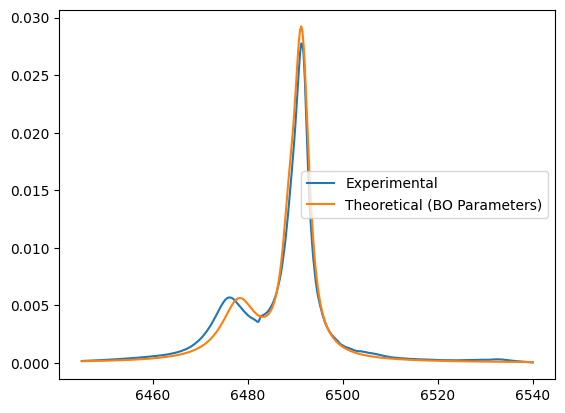

In [24]:
gpd = res.x[0]
stick_x, stick_y = xes_calc.gen_sticks("Mn", "2+", gpd=gpd)
res = xes_fit.min_fit(exp_x, exp_y, stick_x, stick_y)
spec = xes_fit.pvoigt_gen(exp_x, stick_x, stick_y, *res.x)
plt.plot(exp_x, exp_y/np.sum(exp_y), label="Experimental")
plt.plot(exp_x, spec/np.sum(spec), label="Theoretical (BO Parameters)")
plt.legend()
plt.show()